In [1]:
%matplotlib notebook
import torch
from train import Trainer
from model import MVCNN
from build_nn import CNN, ResNet
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from dataset import PowderDataset
import numpy as np
import torchvision.transforms as t
from torch.utils.tensorboard import SummaryWriter

In [ ]:
cnn_dict = {
    "layers" : [3,4,6,3],
    "num_classes" : 3,
    "in_channels" : 1,
    "out_channels" : 512,
    "intermediate_channels" : [64,64,128,256],
    "kernel_sizes" : 5,
    "strides" : [4,4,4,2],
    "avgpool_size" : 8,
    "activation" : "leaky_relu"
}

In [ ]:
cnn = ResNet(**cnn_dict)
# cnn = CNN(**cnn_dict)

In [ ]:
transforms = [t.RandomErasing(), t.RandomAdjustSharpness(0.5), t.RandomAffine(45), t.RandomAutocontrast(), t.RandomHorizontalFlip(), t.RandomVerticalFlip()]

In [ ]:
cnn

In [ ]:
mvcnn = MVCNN(cnn, num_classes=3)

In [ ]:
optimi = optim.Adam(mvcnn.parameters(), lr=1e-3, weight_decay=1e-6, betas=(0.9,0.9))
# optimi = optim.SGD(mvcnn.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-6)

In [ ]:
loss = nn.CrossEntropyLoss()

In [ ]:
sched = optim.lr_scheduler.CosineAnnealingLR(optimi, T_max=20, eta_min=1e-7)
# sched = optim.lr_scheduler.ReduceLROnPlateau(optimi, patience=4, threshold=1e-3)
# sched = optim.lr_scheduler.StepLR(optimi, 20)
# sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimi, T_0=20, eta_min=1e-5, verbose=True)

In [ ]:
trainer = Trainer(mvcnn,optimi,loss,data_pth="D:/gwb21218/segmented_dataset/",scheduler=sched,save_dir="D:/gwb21218/multi_pow/")
# trainer = Trainer(mvcnn,optimi,loss,data_pth="D:/gwb21218/segmented_dataset/",save_dir="D:/gwb21218/multi_pow/")
# trainer = Trainer(mvcnn,optimi,loss,data_pth="segmented_dataset/",save_dir="C:/Users/gwb21218/multi_pow/")

In [ ]:
%%time
trainer.load_data()

In [ ]:
trainer.train_in.shape

In [ ]:
np.savez_compressed("training_data.npz", train_in=trainer.train_in, train_out=trainer.train_out, val_in=trainer.val_in, val_out=trainer.val_out)

In [ ]:
data = np.load("training_data_15.npz")

In [ ]:
%%time
trainer.train_in = data["train_in"]/255
trainer.train_out = data["train_out"]
trainer.val_in = data["val_in"]/255
trainer.val_out = data["val_out"]

In [ ]:
trainer.train_in[0]

In [ ]:
torch.cuda.empty_cache()

In [ ]:
trainer.cool_beauty(num_epochs=2000, batch_size=6, transform=transforms)

In [ ]:
trainer.train_losses

In [ ]:
trainer.val_losses

In [ ]:
trainer.train(DataLoader(TensorDataset(torch.from_numpy(trainer.train_in), torch.from_numpy(trainer.train_out))))

In [ ]:
val_loader = DataLoader(PowderDataset(torch.from_numpy(trainer.val_in), torch.from_numpy(trainer.val_out)), batch_size=1, shuffle=False)

In [ ]:
image, label = iter(val_loader).next()

In [ ]:
image.shape

In [ ]:
label

In [ ]:
trainer.validation(val_loader)

In [ ]:
writer = SummaryWriter("runs/powder_data_3")

In [ ]:
writer.add_graph(mvcnn.cuda(),torch.randn(1,24,1,1024,1024).cuda())

In [ ]:
writer.close()

In [ ]:
torch.distributed.is_available()

# Autoencoder

In [2]:
class Lambda(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, x):
        return self.func(x)

In [3]:
class AE(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, stride=2, kernel_size=7,padding=3),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64,128, stride=2, kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
#             Lambda(lambda x: x.view(x.size(0), -1)),
#             nn.Linear(128*64*64,1000)
            nn.Conv2d(128, 1, stride=1, kernel_size=1)
        )
        
        self.decoder = nn.Sequential(
            nn.Conv2d(1, 128, stride=1, kernel_size=1),
#             nn.Linear(1000,128*64*64),
#             Lambda(lambda x: x.view(x.size(0), 128, 64, 64)),
            nn.ConvTranspose2d(128,64,stride=2,kernel_size=3,padding=1,output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, in_channels, stride=2, kernel_size=3,padding=1,output_padding=1),
            nn.LeakyReLU(),
        )
        
    def forward(self, x):
        h = self.encoder(x)
        out = self.decoder(h)
        
        return out

In [4]:
ae = AE(1).to("cuda:0")

In [ ]:
ae

In [ ]:
ae.to("cuda:0")

In [7]:
data = np.load("training_data_15.npz")

In [8]:
train_in, train_out = data["train_in"], data["train_in"]
val_in, val_out = data["val_in"], data["val_in"]

In [9]:
train_in, train_out = train_in.reshape(-1,1024,1024), train_out.reshape(-1,1024,1024)
val_in, val_out = val_in.reshape(-1,1024,1024), val_out.reshape(-1,1024,1024)

In [11]:
train_in.shape

(2016, 1024, 1024)

In [ ]:
ae(torch.from_numpy(train_in[0]/255).unsqueeze(0).unsqueeze(0).float()).shape

In [10]:
criterion = nn.MSELoss()
optimi = optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-6)
sched = optim.lr_scheduler.StepLR(optimi, 50, verbose=True)

Adjusting learning rate of group 0 to 1.0000e-03.


In [11]:
from torch.utils.data import TensorDataset, DataLoader

In [14]:
train_dataset = TensorDataset(torch.from_numpy(train_in/255).unsqueeze(1), torch.from_numpy(train_out/255).unsqueeze(1))
val_dataset = TensorDataset(torch.from_numpy(val_in/255).unsqueeze(1), torch.from_numpy(val_out/255).unsqueeze(1))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [15]:
from tqdm import tqdm_notebook

In [16]:
for n in range(200):
    batch_losses = []
    for j, (images, labels) in enumerate(tqdm_notebook(train_loader)):
        images, labels = images.float().to("cuda:0"), labels.float().to("cuda:0")

        optimi.zero_grad()
        output = ae(images)
        loss = criterion(output, labels)
        loss.backward()
        optimi.step()

        batch_losses.append(loss.item())

    train_loss = torch.mean(torch.tensor(batch_losses))
        
    batch_val_losses = []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.float().to("cuda:0"), labels.float().to("cuda:0")
            output = ae(images)
            loss = criterion(output, labels)
            
            batch_val_losses.append(loss.item())
            
    val_loss = torch.mean(torch.tensor(batch_val_losses))
    
    sched.step()
        
    print(f"For epoch {n}, train loss = {train_loss}, val loss = {val_loss}")

C:\Users\gwb21218\AppData\Local\Temp\ipykernel_28076\3655264905.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for j, (images, labels) in enumerate(tqdm_notebook(train_loader)):


  0%|          | 0/63 [00:00<?, ?it/s]

Adjusting learning rate of group 0 to 1.0000e-03.
For epoch 0, train loss = 0.19688650965690613, val loss = 0.09186295419931412


  0%|          | 0/63 [00:00<?, ?it/s]

Adjusting learning rate of group 0 to 1.0000e-03.
For epoch 1, train loss = 0.0704183503985405, val loss = 0.04143352434039116


...

Adjusting learning rate of group 0 to 1.0000e-06.
For epoch 197, train loss = 0.0015196683816611767, val loss = 0.0017271549440920353


  0%|          | 0/63 [00:00<?, ?it/s]

Adjusting learning rate of group 0 to 1.0000e-06.
For epoch 198, train loss = 0.0015275499317795038, val loss = 0.0018348504090681672


  0%|          | 0/63 [00:00<?, ?it/s]

Adjusting learning rate of group 0 to 1.0000e-07.
For epoch 199, train loss = 0.0015231622382998466, val loss = 0.0017931879265233874


In [26]:
torch.save(ae.state_dict(), "trained_ae.pth")

In [25]:
ae.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[[[ 0.0444, -0.0833,  0.0669,  ...,  0.0684,  0.0553,  0.1218],
                        [ 0.1229,  0.0708,  0.0940,  ...,  0.0217,  0.0255,  0.0558],
                        [ 0.0587,  0.1513, -0.0646,  ...,  0.1057, -0.0694, -0.0221],
                        ...,
                        [-0.1321, -0.0710,  0.0622,  ...,  0.0875,  0.0839,  0.0467],
                        [ 0.0362, -0.1172, -0.1191,  ...,  0.1067, -0.0828, -0.0802],
                        [-0.0036, -0.0034, -0.1093,  ...,  0.0596,  0.0989,  0.1263]]],
              
              
                      [[[ 0.1288,  0.0468,  0.0031,  ...,  0.0145, -0.0039, -0.0023],
                        [ 0.0031,  0.1191, -0.0507,  ..., -0.0395,  0.0272, -0.0076],
                        [-0.0446,  0.0279,  0.0716,  ...,  0.0449, -0.0182,  0.0316],
                        ...,
                        [ 0.0543, -0.2635, -0.0975,  ...,  0.0615, -0.0277,  0.0155],
                

In [6]:
ae.load_state_dict(torch.load("trained_ae.pth"))

<All keys matched successfully>

In [25]:
with torch.no_grad():
    out = ae(torch.from_numpy(val_in[-1]/255).unsqueeze(0).unsqueeze(0).float().cuda()).squeeze().cpu().numpy()

In [26]:
out.shape

(1024, 1024)

In [27]:
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>


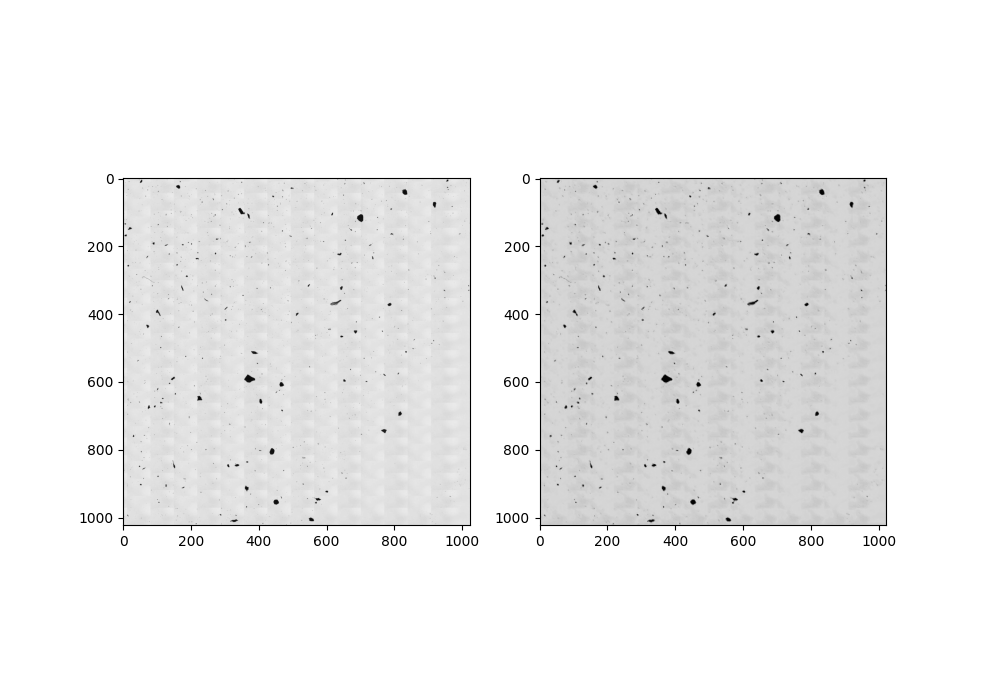

In [29]:
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(val_in[-1], cmap="Greys_r")
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(out, cmap="Greys_r")

In [20]:
with torch.no_grad():
    out = ae.encoder(torch.from_numpy(val_in[60]/255).unsqueeze(0).unsqueeze(0).float().cuda()).squeeze().cpu().numpy()

In [21]:
out.shape

(256, 256)

In [22]:
from matplotlib.colors import PowerNorm

<IPython.core.display.Javascript object>


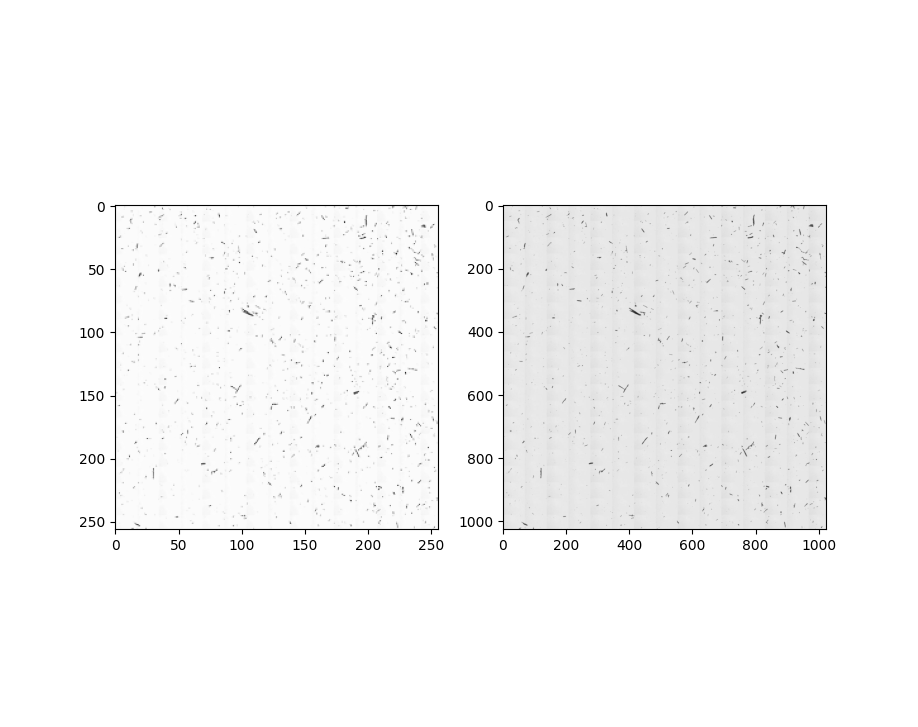

In [24]:
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(out, cmap="Greys_r", norm=PowerNorm(1.2))

ax2 = fig.add_subplot(1,2,2)
ax2.imshow(val_in[60], cmap="Greys_r")